<a href="https://www.pieriandata.com"><img src="../Pierian_Data_Logo.PNG"></a>
<strong><center>Copyright by Pierian Data Inc.</center></strong> 
<strong><center>Created by Jose Marcial Portilla.</center></strong>

# Keras TF 2.0 - Code Along Classification Project

Let's explore a classification task with Keras API for TF 2.0

## The Data

### Breast cancer wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

    :Number of Instances: 569

    :Number of Attributes: 30 numeric, predictive attributes and the class

    :Attribute Information:
        - radius (mean of distances from center to points on the perimeter)
        - texture (standard deviation of gray-scale values)
        - perimeter
        - area
        - smoothness (local variation in radius lengths)
        - compactness (perimeter^2 / area - 1.0)
        - concavity (severity of concave portions of the contour)
        - concave points (number of concave portions of the contour)
        - symmetry 
        - fractal dimension ("coastline approximation" - 1)

        The mean, standard error, and "worst" or largest (mean of the three
        largest values) of these features were computed for each image,
        resulting in 30 features.  For instance, field 3 is Mean Radius, field
        13 is Radius SE, field 23 is Worst Radius.

        - class:
                - WDBC-Malignant
                - WDBC-Benign

    :Summary Statistics:

    ===================================== ====== ======
                                           Min    Max
    ===================================== ====== ======
    radius (mean):                        6.981  28.11
    texture (mean):                       9.71   39.28
    perimeter (mean):                     43.79  188.5
    area (mean):                          143.5  2501.0
    smoothness (mean):                    0.053  0.163
    compactness (mean):                   0.019  0.345
    concavity (mean):                     0.0    0.427
    concave points (mean):                0.0    0.201
    symmetry (mean):                      0.106  0.304
    fractal dimension (mean):             0.05   0.097
    radius (standard error):              0.112  2.873
    texture (standard error):             0.36   4.885
    perimeter (standard error):           0.757  21.98
    area (standard error):                6.802  542.2
    smoothness (standard error):          0.002  0.031
    compactness (standard error):         0.002  0.135
    concavity (standard error):           0.0    0.396
    concave points (standard error):      0.0    0.053
    symmetry (standard error):            0.008  0.079
    fractal dimension (standard error):   0.001  0.03
    radius (worst):                       7.93   36.04
    texture (worst):                      12.02  49.54
    perimeter (worst):                    50.41  251.2
    area (worst):                         185.2  4254.0
    smoothness (worst):                   0.071  0.223
    compactness (worst):                  0.027  1.058
    concavity (worst):                    0.0    1.252
    concave points (worst):               0.0    0.291
    symmetry (worst):                     0.156  0.664
    fractal dimension (worst):            0.055  0.208
    ===================================== ====== ======

    :Missing Attribute Values: None

    :Class Distribution: 212 - Malignant, 357 - Benign

    :Creator:  Dr. William H. Wolberg, W. Nick Street, Olvi L. Mangasarian

    :Donor: Nick Street

    :Date: November, 1995

This is a copy of UCI ML Breast Cancer Wisconsin (Diagnostic) datasets.
https://goo.gl/U2Uwz2

Features are computed from a digitized image of a fine needle
aspirate (FNA) of a breast mass.  They describe
characteristics of the cell nuclei present in the image.

Separating plane described above was obtained using
Multisurface Method-Tree (MSM-T) [K. P. Bennett, "Decision Tree
Construction Via Linear Programming." Proceedings of the 4th
Midwest Artificial Intelligence and Cognitive Science Society,
pp. 97-101, 1992], a classification method which uses linear
programming to construct a decision tree.  Relevant features
were selected using an exhaustive search in the space of 1-4
features and 1-3 separating planes.

The actual linear program used to obtain the separating plane
in the 3-dimensional space is that described in:
[K. P. Bennett and O. L. Mangasarian: "Robust Linear
Programming Discrimination of Two Linearly Inseparable Sets",
Optimization Methods and Software 1, 1992, 23-34].

This database is also available through the UW CS ftp server:

ftp ftp.cs.wisc.edu
cd math-prog/cpo-dataset/machine-learn/WDBC/

.. topic:: References

   - W.N. Street, W.H. Wolberg and O.L. Mangasarian. Nuclear feature extraction 
     for breast tumor diagnosis. IS&T/SPIE 1993 International Symposium on 
     Electronic Imaging: Science and Technology, volume 1905, pages 861-870,
     San Jose, CA, 1993.
   - O.L. Mangasarian, W.N. Street and W.H. Wolberg. Breast cancer diagnosis and 
     prognosis via linear programming. Operations Research, 43(4), pages 570-577, 
     July-August 1995.
   - W.H. Wolberg, W.N. Street, and O.L. Mangasarian. Machine learning techniques
     to diagnose breast cancer from fine-needle aspirates. Cancer Letters 77 (1994) 
     163-171.

In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv('../DATA/cancer_classification.csv')

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [4]:
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
mean texture,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
mean area,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
mean compactness,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
mean concavity,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
mean concave points,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
mean symmetry,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


## EDA

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

In [6]:
df.head(5)

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,benign_0__mal_1
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


<Axes: xlabel='benign_0__mal_1', ylabel='count'>

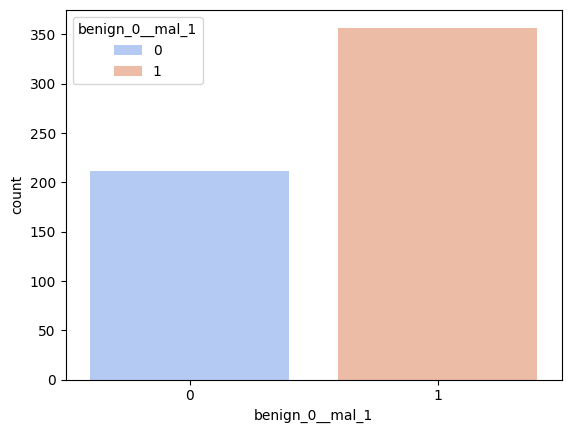

In [7]:
sns.countplot(x='benign_0__mal_1',data=df, hue='benign_0__mal_1',palette='coolwarm')

<Axes: >

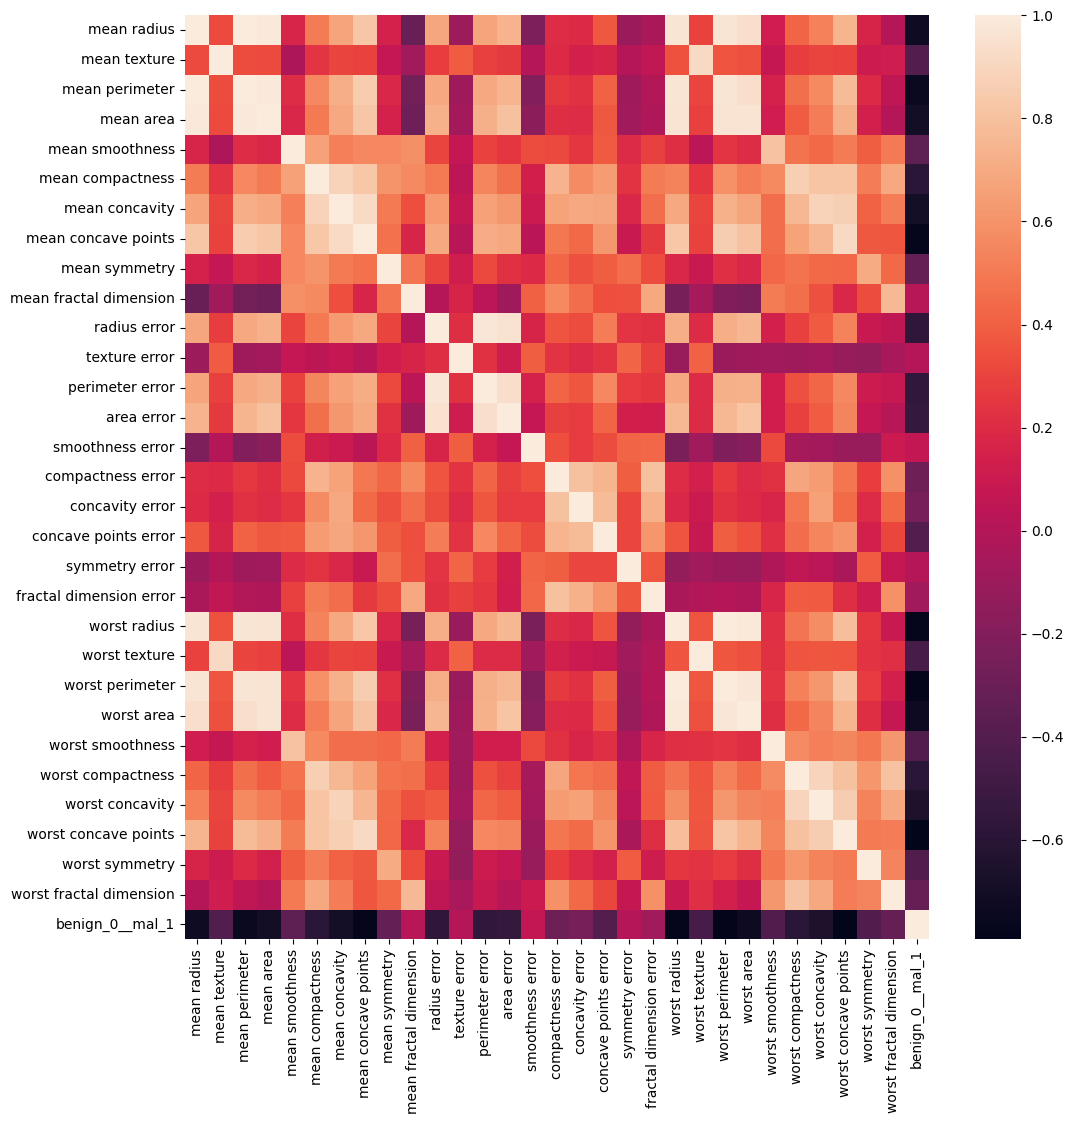

In [14]:
plt.figure(figsize=(12,12))
sns.heatmap(df.corr())

In [9]:
df.corr()['benign_0__mal_1'].sort_values()

worst concave points      -0.793566
worst perimeter           -0.782914
mean concave points       -0.776614
worst radius              -0.776454
mean perimeter            -0.742636
worst area                -0.733825
mean radius               -0.730029
mean area                 -0.708984
mean concavity            -0.696360
worst concavity           -0.659610
mean compactness          -0.596534
worst compactness         -0.590998
radius error              -0.567134
perimeter error           -0.556141
area error                -0.548236
worst texture             -0.456903
worst smoothness          -0.421465
worst symmetry            -0.416294
mean texture              -0.415185
concave points error      -0.408042
mean smoothness           -0.358560
mean symmetry             -0.330499
worst fractal dimension   -0.323872
compactness error         -0.292999
concavity error           -0.253730
fractal dimension error   -0.077972
symmetry error             0.006522
texture error              0

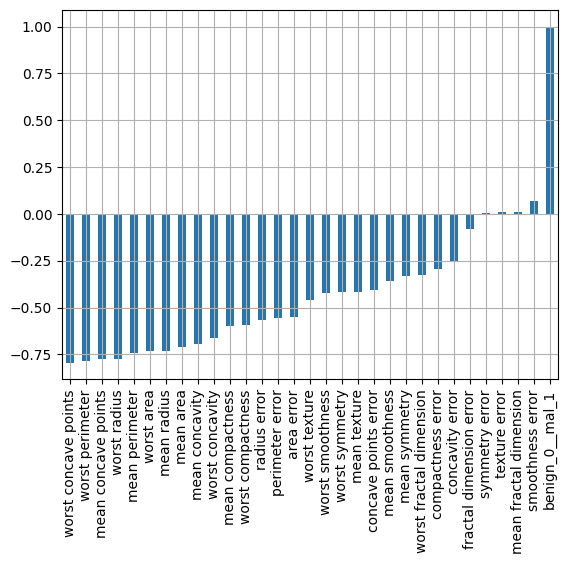

In [12]:
df.corr()['benign_0__mal_1'].sort_values().plot(kind='bar')
plt.grid()

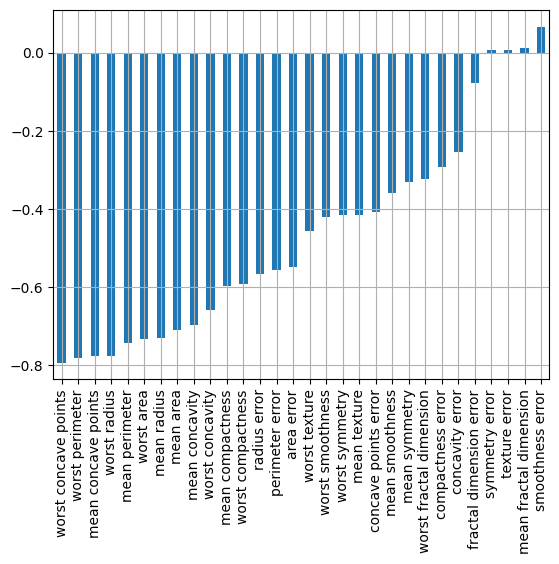

In [13]:
df.corr()['benign_0__mal_1'][:-1].sort_values().plot(kind='bar')
plt.grid()

## Train Test Split

In [15]:
X = df.drop('benign_0__mal_1',axis=1).values
y = df['benign_0__mal_1'].values

In [17]:
X

array([[1.799e+01, 1.038e+01, 1.228e+02, ..., 2.654e-01, 4.601e-01,
        1.189e-01],
       [2.057e+01, 1.777e+01, 1.329e+02, ..., 1.860e-01, 2.750e-01,
        8.902e-02],
       [1.969e+01, 2.125e+01, 1.300e+02, ..., 2.430e-01, 3.613e-01,
        8.758e-02],
       ...,
       [1.660e+01, 2.808e+01, 1.083e+02, ..., 1.418e-01, 2.218e-01,
        7.820e-02],
       [2.060e+01, 2.933e+01, 1.401e+02, ..., 2.650e-01, 4.087e-01,
        1.240e-01],
       [7.760e+00, 2.454e+01, 4.792e+01, ..., 0.000e+00, 2.871e-01,
        7.039e-02]], shape=(569, 30))

In [18]:
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
       1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
       1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0,
       0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1,
       1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0,
       0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0,
       1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0,

In [16]:
from sklearn.model_selection import train_test_split

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.25,random_state=101)


## Scaling Data

In [20]:
from sklearn.preprocessing import MinMaxScaler

In [21]:
scaler = MinMaxScaler()

In [22]:
scaler.fit(X_train)

,feature_range,"(0, ...)"
,copy,True
,clip,False


In [23]:
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

## Creating the Model

    # For a binary classification problem
    model.compile(optimizer='rmsprop',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
                  
    

In [24]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation,Dropout

In [25]:
X_train.shape

(426, 30)

In [26]:
model = Sequential()

# https://stats.stackexchange.com/questions/181/how-to-choose-the-number-of-hidden-layers-and-nodes-in-a-feedforward-neural-netw

model.add(Dense(units=30,activation='relu'))

model.add(Dense(units=15,activation='relu'))


# Binary Classification Problem
model.add(Dense(units=1,activation='sigmoid'))

# For a binary classification problem
model.compile(loss='binary_crossentropy', optimizer='adam')

## Training the Model 

### Example One: Choosing too many epochs and overfitting!

In [27]:
# https://stats.stackexchange.com/questions/164876/tradeoff-batch-size-vs-number-of-iterations-to-train-a-neural-network
# https://datascience.stackexchange.com/questions/18414/are-there-any-rules-for-choosing-the-size-of-a-mini-batch

model.fit(x=X_train, 
          y=y_train, 
          epochs=600,
          validation_data=(X_test, y_test), verbose=1
          )

Epoch 1/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - loss: 0.6711 - val_loss: 0.6576
Epoch 2/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.6377 - val_loss: 0.6225
Epoch 3/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.5976 - val_loss: 0.5760
Epoch 4/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.5459 - val_loss: 0.5237
Epoch 5/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.4964 - val_loss: 0.4743
Epoch 6/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.4482 - val_loss: 0.4245
Epoch 7/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.3996 - val_loss: 0.3758
Epoch 8/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.3545 - val_loss: 0.3320
Epoch 9/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.3168 - val_loss: 0.2956
Epoch 10/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.2856 - val_loss: 0.2669
Epoch 11/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.2599 - val_loss: 0.2435
Epoch 12/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step

In [28]:
model.history.history

{'loss': [0.6711397171020508,
  0.6377357244491577,
  0.5975987315177917,
  0.5459462404251099,
  0.496418297290802,
  0.44823476672172546,
  0.3996134400367737,
  0.35450035333633423,
  0.3167893886566162,
  0.2855658233165741,
  0.2599387466907501,
  0.24254553020000458,
  0.22503581643104553,
  0.2105291783809662,
  0.19554731249809265,
  0.18593448400497437,
  0.17568978667259216,
  0.16580556333065033,
  0.15674619376659393,
  0.14852109551429749,
  0.14072361588478088,
  0.13400602340698242,
  0.13131214678287506,
  0.12230513244867325,
  0.11776317656040192,
  0.1133464127779007,
  0.10966623574495316,
  0.10346122831106186,
  0.10016850382089615,
  0.09837688505649567,
  0.09662073105573654,
  0.09303561598062515,
  0.08880078792572021,
  0.09030470252037048,
  0.08529175817966461,
  0.08273153007030487,
  0.0783902257680893,
  0.07743020355701447,
  0.07727706432342529,
  0.07315672188997269,
  0.0713963732123375,
  0.07123260200023651,
  0.06947990506887436,
  0.0685721263289

In [29]:
model_loss = pd.DataFrame(model.history.history)

In [30]:
model_loss

,loss,val_loss
0,0.671140,0.657642
1,0.637736,0.622544
2,0.597599,0.576010
3,0.545946,0.523709
4,0.496418,0.474301
...,...,...
595,0.005106,0.242866
596,0.005137,0.247108
597,0.005221,0.241491
598,0.006109,0.274596


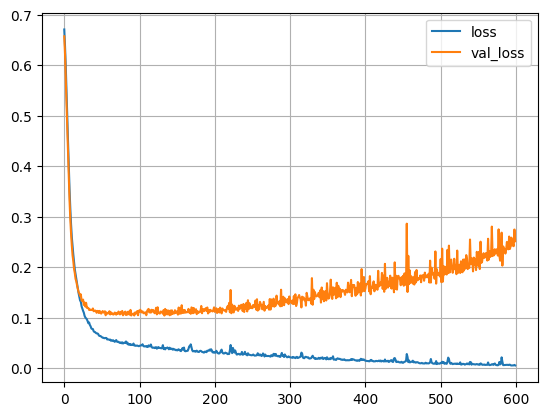

In [32]:
model_loss.plot()
plt.grid()

## Example Two: Early Stopping

We obviously trained too much! Let's use early stopping to track the val_loss and stop training once it begins increasing too much!

In [34]:
model = Sequential()
model.add(Dense(units=30,activation='relu'))
model.add(Dense(units=15,activation='relu'))
model.add(Dense(units=1,activation='sigmoid'))
model.compile(loss='binary_crossentropy', optimizer='adam')

In [33]:
from tensorflow.keras.callbacks import EarlyStopping

Stop training when a monitored quantity has stopped improving.

    Arguments:
        monitor: Quantity to be monitored.
        min_delta: Minimum change in the monitored quantity
            to qualify as an improvement, i.e. an absolute
            change of less than min_delta, will count as no
            improvement.
        patience: Number of epochs with no improvement
            after which training will be stopped.
        verbose: verbosity mode.
        mode: One of `{"auto", "min", "max"}`. In `min` mode,
            training will stop when the quantity
            monitored has stopped decreasing; in `max`
            mode it will stop when the quantity
            monitored has stopped increasing; in `auto`
            mode, the direction is automatically inferred
            from the name of the monitored quantity.

In [35]:
early_stop = EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=25)

In [36]:
model.fit(x=X_train, 
          y=y_train, 
          epochs=600,
          validation_data=(X_test, y_test), verbose=1,
          callbacks=[early_stop]
          )

Epoch 1/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 4s 47ms/step - loss: 0.7024 - val_loss: 0.6784
Epoch 2/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.6557 - val_loss: 0.6392
Epoch 3/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.6144 - val_loss: 0.5999
Epoch 4/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.5703 - val_loss: 0.5505
Epoch 5/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.5202 - val_loss: 0.4960
Epoch 6/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.4710 - val_loss: 0.4417
Epoch 7/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.4231 - val_loss: 0.3943
Epoch 8/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.3795 - val_loss: 0.3509
Epoch 9/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.3437 - val_loss: 0.3136
Epoch 10/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.3104 - val_loss: 0.2818
Epoch 11/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.2824 - val_loss: 0.2555
Epoch 12/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step

In [37]:
model.history.history

{'loss': [0.7023852467536926,
  0.655707836151123,
  0.6143777966499329,
  0.5702674388885498,
  0.5201559662818909,
  0.47096019983291626,
  0.4230571389198303,
  0.37948504090309143,
  0.34370309114456177,
  0.3104168474674225,
  0.28242915868759155,
  0.25828680396080017,
  0.241053968667984,
  0.22142362594604492,
  0.20540492236614227,
  0.1907612383365631,
  0.1795896589756012,
  0.16909390687942505,
  0.15868273377418518,
  0.1507638543844223,
  0.14207181334495544,
  0.1348458081483841,
  0.1278178095817566,
  0.12134876847267151,
  0.11529789865016937,
  0.11018535494804382,
  0.11329176276922226,
  0.10523095726966858,
  0.1026366651058197,
  0.0939042791724205,
  0.0949908122420311,
  0.09378230571746826,
  0.08678370714187622,
  0.08305279910564423,
  0.08106803148984909,
  0.08020608872175217,
  0.07687518745660782,
  0.07635878026485443,
  0.075727179646492,
  0.07272873818874359,
  0.07094760984182358,
  0.07146129012107849,
  0.06848538666963577,
  0.06688828766345978,


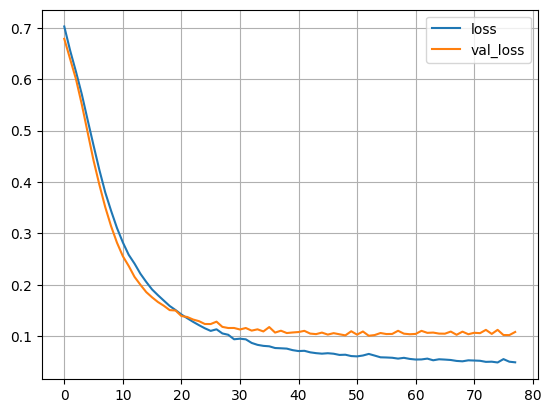

In [38]:
model_loss = pd.DataFrame(model.history.history)
model_loss.plot()
plt.grid()

## Example Three: Adding in DropOut Layers

In [39]:
from tensorflow.keras.layers import Dropout

In [40]:
model = Sequential()
model.add(Dense(units=30,activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(units=15,activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(units=1,activation='sigmoid'))
model.compile(loss='binary_crossentropy', optimizer='adam')

In [41]:
model.fit(x=X_train, 
          y=y_train, 
          epochs=600,
          validation_data=(X_test, y_test), verbose=1,
          callbacks=[early_stop]
          )

Epoch 1/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 6s 40ms/step - loss: 0.6889 - val_loss: 0.6729
Epoch 2/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.6799 - val_loss: 0.6579
Epoch 3/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.6710 - val_loss: 0.6440
Epoch 4/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.6566 - val_loss: 0.6244
Epoch 5/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 69ms/step - loss: 0.6452 - val_loss: 0.6009
Epoch 6/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.6169 - val_loss: 0.5755
Epoch 7/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.6058 - val_loss: 0.5529
Epoch 8/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.5834 - val_loss: 0.5243
Epoch 9/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.5769 - val_loss: 0.4945
Epoch 10/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.5204 - val_loss: 0.4620
Epoch 11/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.5021 - val_loss: 0.4257
Epoch 12/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step

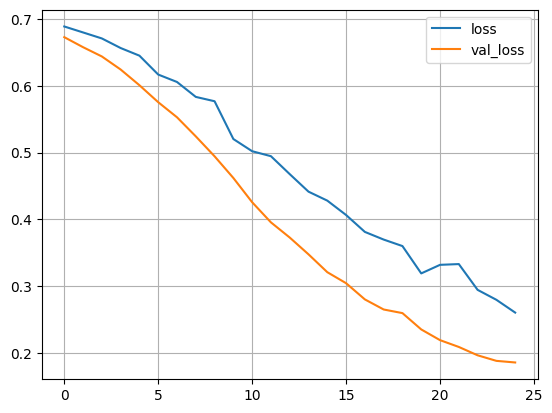

In [42]:
model_loss = pd.DataFrame(model.history.history)
model_loss.plot()
plt.grid()

# Model Evaluation

In [44]:
probabilities = model.predict(X_test)
predictions = (probabilities > 0.5).astype("int32")

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step


In [45]:
from sklearn.metrics import classification_report,confusion_matrix

In [46]:
# https://en.wikipedia.org/wiki/Precision_and_recall
print(classification_report(y_test,predictions))

              precision    recall  f1-score   support

           0       0.90      0.98      0.94        55
           1       0.99      0.93      0.96        88

    accuracy                           0.95       143
   macro avg       0.94      0.96      0.95       143
weighted avg       0.95      0.95      0.95       143



In [47]:
print(confusion_matrix(y_test,predictions))

[[54  1]
 [ 6 82]]
